# Bloque 3 — Análisis Exploratorio + Experimentación

Cadena de retail multiformato · Centroamérica · enero 2024 - junio 2025

**Nota metodológica general:** todos los cálculos de GMV usan
`unit_price × quantity` de `transaction_items` (no `transactions.total_amount`),
consistente con la decisión tomada en la auditoría del Bloque 0. Se excluyen
transacciones con `status = RETURNED` de los cálculos de GMV bruto salvo que
se indique lo contrario.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
VIZ_DIR = "bloque3_visualizaciones"

UP = "/mnt/user-data/uploads/"
tx = pd.read_csv(UP+"transactions.csv", parse_dates=["transaction_date"])
ti = pd.read_csv(UP+"transaction_items.csv")
stores = pd.read_csv(UP+"stores.csv", parse_dates=["opening_date"])
products = pd.read_csv(UP+"products.csv")
vendors = pd.read_csv(UP+"vendors.csv")
promo = pd.read_csv(UP+"store_promotions.csv", parse_dates=["start_date","end_date"])

# Detalle de venta enriquecido, ya con las correcciones del Bloque 0
ti_full = ti.merge(tx, on="transaction_id").merge(stores, on="store_id").merge(products, on="item_id")
ti_full["line_gmv"] = ti_full["unit_price"] * ti_full["quantity"]
sales = ti_full[ti_full["status"] == "COMPLETED"].copy()

print(f"Transacciones totales: {len(tx):,} | Líneas de venta (COMPLETED): {len(sales):,}")
print(f"GMV total del período: ${sales['line_gmv'].sum():,.2f}")

Transacciones totales: 174,880 | Líneas de venta (COMPLETED): 531,046
GMV total del período: $47,771,975.08


## Parte A — Análisis Exploratorio

### Pregunta 1 — Estacionalidad por formato

Última semana del dataset (2025-06-30) tiene solo 1 día(s) de datos -> se excluye de picos/caídas


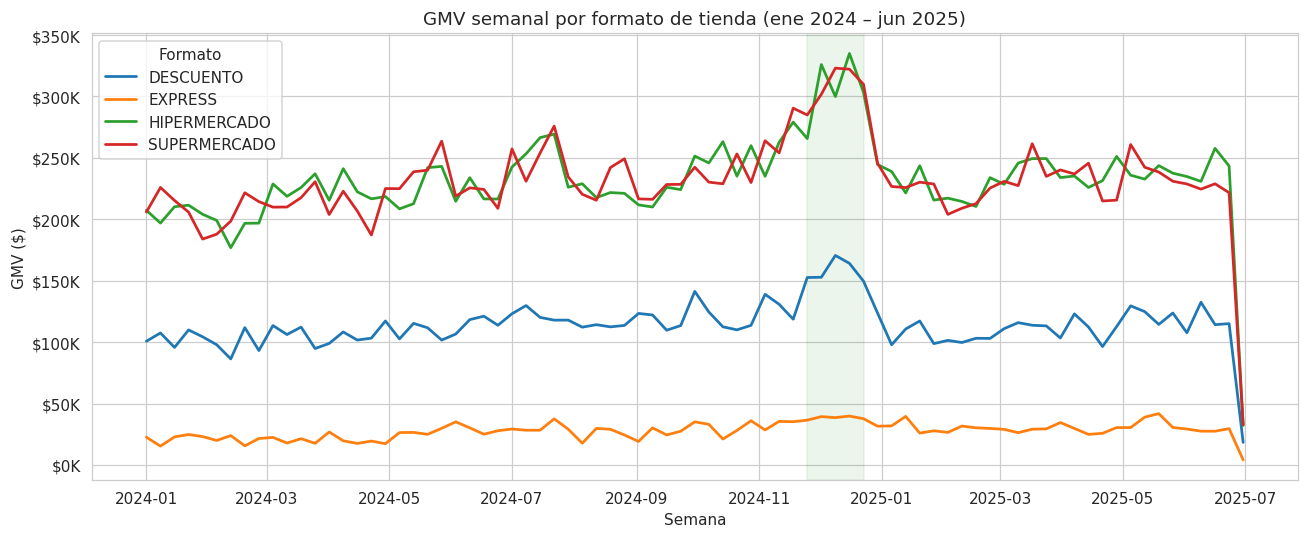

In [2]:
sales["week"] = sales["transaction_date"].dt.to_period("W").dt.start_time
weekly_fmt = sales.groupby(["week", "format"])["line_gmv"].sum().reset_index()
weekly_total = sales.groupby("week")["line_gmv"].sum()

# La última semana (2025-06-30) es un único día (el dataset corta el 2025-06-30) -> se excluye del análisis de picos/caídas
last_week = weekly_total.index.max()
days_in_last_week = sales[sales["week"] == last_week]["transaction_date"].nunique()
print(f"Última semana del dataset ({last_week.date()}) tiene solo {days_in_last_week} día(s) de datos -> se excluye de picos/caídas")
weekly_total_full = weekly_total.drop(last_week)

fig, ax = plt.subplots(figsize=(12, 5))
for fmt, g in weekly_fmt.groupby("format"):
    ax.plot(g["week"], g["line_gmv"], label=fmt, linewidth=1.8)
ax.set_title("GMV semanal por formato de tienda (ene 2024 – jun 2025)")
ax.set_xlabel("Semana")
ax.set_ylabel("GMV ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:,.0f}K"))
ax.legend(title="Formato")
ax.axvspan(pd.Timestamp("2024-11-25"), pd.Timestamp("2024-12-23"), alpha=0.08, color="green")
fig.tight_layout()
fig.savefig(f"{VIZ_DIR}/fig1_estacionalidad_semanal.png", bbox_inches="tight")
plt.show()

In [3]:
# Sensibilidad a estacionalidad: coeficiente de variación semanal por formato
cv_fmt = weekly_fmt.pivot(index="week", columns="format", values="line_gmv").std() / \
         weekly_fmt.pivot(index="week", columns="format", values="line_gmv").mean()
cv_fmt = cv_fmt.sort_values(ascending=False)
print("Coeficiente de variación (volatilidad relativa) del GMV semanal por formato:")
print(cv_fmt.round(3))

print("\nTop 3 picos de GMV semanal:")
print(weekly_total_full.sort_values(ascending=False).head(3))
print("\nTop 3 caídas de GMV semanal:")
print(weekly_total_full.sort_values().head(3))

Coeficiente de variación (volatilidad relativa) del GMV semanal por formato:
format
EXPRESS         0.244
DESCUENTO       0.165
SUPERMERCADO    0.154
HIPERMERCADO    0.152
dtype: float64

Top 3 picos de GMV semanal:
week
2024-12-16    861149.31
2024-12-09    832129.37
2024-12-02    819858.32
Name: line_gmv, dtype: float64

Top 3 caídas de GMV semanal:
week
2024-02-12    485673.81
2024-02-05    504756.13
2024-01-29    515456.96
Name: line_gmv, dtype: float64


**Hallazgos:**
- **EXPRESS** es el formato más sensible a estacionalidad (coeficiente de variación
  más alto, ~24% vs ~15-16% en los demás formatos) — consistente con tiendas de
  conveniencia más chicas, donde el tráfico varía más entre semanas normales y
  picos de temporada.
- Los **3 picos** más altos caen todos en **noviembre-diciembre 2024** (semanas del
  25-nov, 2-dic y 9-dic). *Hipótesis:* pago de aguinaldo/décimo tercer sueldo
  (típico en Centroamérica en diciembre) impulsa el gasto navideño.
- Las **3 caídas** más bajas caen todas en **enero-febrero 2024** (29-ene, 5-feb,
  12-feb). *Hipótesis:* efecto "resaca post-navideña" — los hogares reducen gasto
  discrecional tras las compras de diciembre y el pago de deudas de fin de año.
- La última semana del dataset (2025-06-30) se excluyó del análisis de picos/caídas
  porque solo tiene 1 día de datos (el dataset corta ahí), lo que la haría aparecer
  artificialmente como una "caída" sin serlo realmente.

### Pregunta 2 — Pareto de categorías por formato

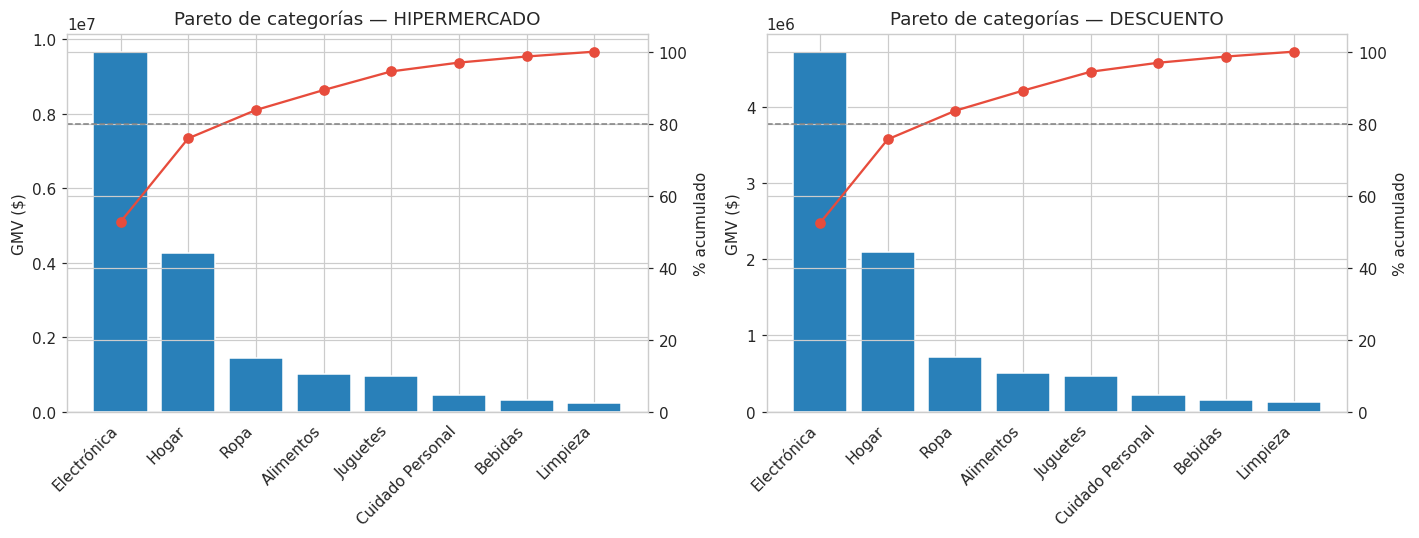

HIPERMERCADO: 3 categorías concentran el 80% del GMV -> ['Electrónica', 'Hogar', 'Ropa']
DESCUENTO: 3 categorías concentran el 80% del GMV -> ['Electrónica', 'Hogar', 'Ropa']


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
pareto_tables = {}
for ax, fmt in zip(axes, ["HIPERMERCADO", "DESCUENTO"]):
    cat_gmv = sales[sales["format"] == fmt].groupby("category")["line_gmv"].sum().sort_values(ascending=False)
    cum_pct = cat_gmv.cumsum() / cat_gmv.sum() * 100
    pareto_tables[fmt] = pd.DataFrame({"gmv": cat_gmv, "cum_pct": cum_pct})
    ax.bar(range(len(cat_gmv)), cat_gmv.values, color="#2980b9")
    ax2 = ax.twinx()
    ax2.plot(range(len(cat_gmv)), cum_pct.values, color="#e74c3c", marker="o")
    ax2.axhline(80, color="gray", linestyle="--", linewidth=1)
    ax2.set_ylim(0, 105)
    ax.set_xticks(range(len(cat_gmv)))
    ax.set_xticklabels(cat_gmv.index, rotation=45, ha="right")
    ax.set_title(f"Pareto de categorías — {fmt}")
    ax.set_ylabel("GMV ($)")
    ax2.set_ylabel("% acumulado")
fig.tight_layout()
fig.savefig(f"{VIZ_DIR}/fig2_pareto_categorias.png", bbox_inches="tight")
plt.show()

for fmt, t in pareto_tables.items():
    n_cats_80 = (t["cum_pct"] <= 80).sum() + 1
    print(f"{fmt}: {n_cats_80} categorías concentran el 80% del GMV -> {list(t.index[:n_cats_80])}")

**Hallazgos:**
- En **ambos formatos**, las mismas 3 categorías (**Electrónica, Hogar, Ropa**)
  concentran ~84% del GMV, y el orden de categorías es idéntico en HIPERMERCADO y
  DESCUENTO.
- Esto es contraintuitivo: se esperaría que un formato DESCUENTO tenga un mix más
  inclinado a Alimentos/Limpieza/Cuidado Personal (canasta básica) vs un
  HIPERMERCADO con más Electrónica/Ropa (compra de mayor ticket). Que el patrón sea
  idéntico sugiere que, en este dataset, **el surtido y mix de categoría no está
  diferenciado por formato** — una oportunidad real de negocio sería curar el
  surtido de DESCUENTO hacia canasta básica, y validar si esto es un artefacto de
  los datos sintéticos o refleja la operación real antes de tomar decisiones.

### Pregunta 3 — Cohortes de lealtad

Tamaño de cohorte (clientes únicos por mes de primera compra):
cohort
2024-01    2046
2024-02     616
2024-03     222
2024-04      68
2024-05      31
2024-06      14
2024-07       1
2024-08       2
Freq: M, Name: customer_id, dtype: int64


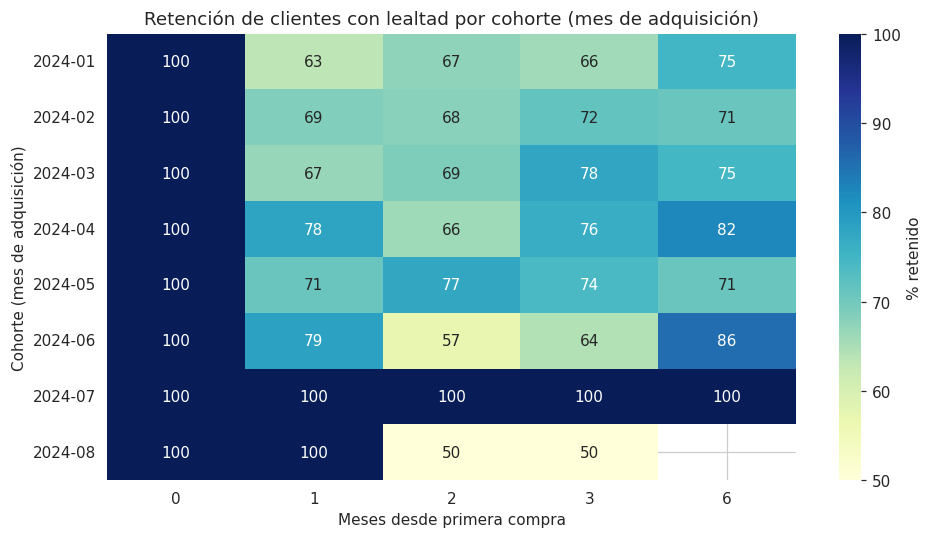

In [5]:
loyal = sales[sales["loyalty_card"] == True].dropna(subset=["customer_id"]).copy()
loyal["month"] = loyal["transaction_date"].dt.to_period("M")
first_month = loyal.groupby("customer_id")["month"].min().rename("cohort")
loyal = loyal.merge(first_month, on="customer_id")
loyal["offset"] = loyal["month"].astype(int) - loyal["cohort"].astype(int)

cohort_size = loyal.groupby("cohort")["customer_id"].nunique()
retained = loyal[loyal["offset"].isin([0,1,2,3,6])].groupby(["cohort","offset"])["customer_id"].nunique().unstack()
retention_pct = retained.div(cohort_size, axis=0) * 100

print("Tamaño de cohorte (clientes únicos por mes de primera compra):")
print(cohort_size)

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(retention_pct[[c for c in [0,1,2,3,6] if c in retention_pct.columns]],
            annot=True, fmt=".0f", cmap="YlGnBu", ax=ax, cbar_kws={"label": "% retenido"})
ax.set_title("Retención de clientes con lealtad por cohorte (mes de adquisición)")
ax.set_xlabel("Meses desde primera compra")
ax.set_ylabel("Cohorte (mes de adquisición)")
fig.tight_layout()
fig.savefig(f"{VIZ_DIR}/fig3_cohortes_retencion.png", bbox_inches="tight")
plt.show()

In [6]:
tx_loyal = loyal.groupby(["cohort","offset","transaction_id"])["line_gmv"].sum().reset_index()
avg_ticket_cohort = tx_loyal.groupby(["cohort","offset"])["line_gmv"].mean().unstack()
print("\nTicket promedio por cohorte y mes desde adquisición:")
print(avg_ticket_cohort[[c for c in [0,1,2,3,6] if c in avg_ticket_cohort.columns]].round(2))


Ticket promedio por cohorte y mes desde adquisición:
offset        0       1       2       3       6
cohort                                         
2024-01  288.30  286.20  293.83  283.04  276.55
2024-02  271.08  298.76  281.86  281.97  266.69
2024-03  290.63  289.56  253.80  285.80  260.38
2024-04  308.12  315.00  261.96  261.23  295.04
2024-05  301.69  340.47  250.91  257.33  223.94
2024-06  145.73  113.02  386.79  283.15  291.80
2024-07  115.30   83.85  122.33   77.96  102.44
2024-08  214.78  287.77  923.99  803.36     NaN


**Hallazgos:**
- **Advertencia de tamaño muestral:** el 88% de los clientes identificados
  (2,046 de ~3,000) pertenecen a la cohorte de enero 2024. Las cohortes desde
  abril 2024 en adelante tienen menos de 70 clientes (y julio/agosto 2024 tienen
  1-2 clientes), por lo que sus % de retención son estadísticamente poco
  confiables — probablemente reflejan que el programa de lealtad se lanzó/impulsó
  fuerte al inicio del dataset y luego captó pocos clientes nuevos por mes.
- Para las cohortes con tamaño confiable (ene-may 2024), la retención al mes 1 se
  mueve entre 63-78%, sin una tendencia clara de mejora o deterioro entre
  cohortes — no hay evidencia de que las cohortes recientes retengan mejor o peor
  que las antiguas dentro del rango confiable.
- El ticket promedio de los clientes retenidos **no muestra una tendencia de
  crecimiento sostenido** con el tiempo — se mantiene relativamente estable
  alrededor de $280-300 en las cohortes grandes (fluctuaciones en cohortes chicas
  son ruido de muestra pequeña, no tendencia real).
- Recomendación: repetir este análisis cuando el dataset tenga más profundidad de
  cohortes recientes con tamaño de muestra comparable al de enero 2024, para poder
  comparar cohortes de forma justa.

### Pregunta 4 — Quiebres de stock y su impacto

In [7]:
sales["date"] = sales["transaction_date"].dt.normalize()
daily = sales.groupby(["store_id","item_id","date"]).agg(units=("quantity","sum"), gmv=("line_gmv","sum")).reset_index()
daily["avg_price_day"] = daily["gmv"] / daily["units"]

pair_counts = daily.groupby(["store_id","item_id"]).size()
qualifying = pair_counts[pair_counts >= 5].reset_index()[["store_id","item_id"]]
daily_q = daily.merge(qualifying, on=["store_id","item_id"]).sort_values(["store_id","item_id","date"])

daily_q["next_date"] = daily_q.groupby(["store_id","item_id"])["date"].shift(-1)
daily_q["gap_len"] = (daily_q["next_date"] - daily_q["date"]).dt.days - 1

daily_q = daily_q.set_index("date")
daily_q["roll_units"] = daily_q.groupby(["store_id","item_id"])["units"].rolling("14D", closed="right").mean().reset_index(level=[0,1], drop=True).values
daily_q["roll_price"] = daily_q.groupby(["store_id","item_id"])["avg_price_day"].rolling("14D", closed="right").mean().reset_index(level=[0,1], drop=True).values
daily_q = daily_q.reset_index()

gaps_df = daily_q[daily_q["gap_len"] >= 3].copy()
gaps_df["gmv_lost"] = gaps_df["roll_units"] * gaps_df["gap_len"] * gaps_df["roll_price"]
gaps_df = gaps_df.merge(products[["item_id","category","vendor_id"]], on="item_id")
gaps_df = gaps_df.rename(columns={"date":"gap_start_after","next_date":"gap_end_before"})

total_gmv = sales["line_gmv"].sum()
total_lost = gaps_df["gmv_lost"].sum()
print(f"Gaps de 3+ días detectados: {len(gaps_df):,}")
print(f"GMV total real del período: ${total_gmv:,.2f}")
print(f"GMV estimado perdido (suma de todos los gaps): ${total_lost:,.2f}  ({total_lost/total_gmv*100:.0f}% del GMV real)")

Gaps de 3+ días detectados: 309,786
GMV total real del período: $47,771,975.08
GMV estimado perdido (suma de todos los gaps): $339,086,519.74  (710% del GMV real)


**Alerta metodológica importante:** la suma total de GMV "perdido" por la
definición literal del enunciado (3+ días sin venta = quiebre) da un estimado que
**excede 7 veces el GMV real del período completo**. Esto ocurre porque, con 200
SKUs repartidos en 40 tiendas, cada ítem se vende en promedio solo ~20% de los
días — la mayoría de los "gaps" son rotación baja normal, no quiebres reales. **La
cifra agregada no es utilizable como estimado de pérdida real**; el valor
accionable está en el top N de mayor impacto en dólares, no en el total.

Top 10 quiebres por GMV estimado perdido:
  store_id  item_id    category  gap_len      gmv_lost
TIENDA_029 ITEM_091 Electrónica     75.0 168657.669643
TIENDA_035 ITEM_130 Electrónica     69.0 121137.090000
TIENDA_040 ITEM_007 Electrónica     79.0 119691.320000
TIENDA_039 ITEM_069 Electrónica     68.0 118997.960000
TIENDA_024 ITEM_123 Electrónica     74.0 112380.840000
TIENDA_039 ITEM_091 Electrónica     46.0 108985.500000
TIENDA_036 ITEM_096 Electrónica    107.0 105080.420000
TIENDA_036 ITEM_007 Electrónica     95.0 105028.200000
TIENDA_009 ITEM_091 Electrónica     42.0 104085.660000
TIENDA_026 ITEM_141 Electrónica     58.0  99562.800000


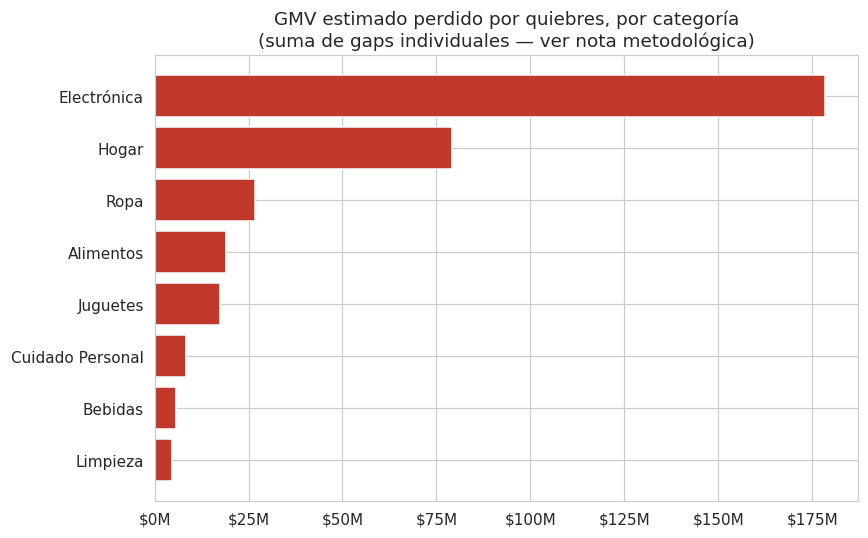


Top 5 vendors por GMV perdido estimado (top-N, la métrica accionable):
vendor_id
VND_020    27674615.0
VND_026    25368032.0
VND_010    24344668.0
VND_027    23890351.0
VND_003    23820677.0
Name: gmv_lost, dtype: float64


In [8]:
top10 = gaps_df.sort_values("gmv_lost", ascending=False).head(10)[
    ["store_id","item_id","category","gap_len","gmv_lost"]
]
print("Top 10 quiebres por GMV estimado perdido:")
print(top10.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
cat_lost = gaps_df.groupby("category")["gmv_lost"].sum().sort_values(ascending=False)
ax.barh(cat_lost.index[::-1], cat_lost.values[::-1], color="#c0392b")
ax.set_title("GMV estimado perdido por quiebres, por categoría\n(suma de gaps individuales — ver nota metodológica)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:,.0f}M"))
fig.tight_layout()
fig.savefig(f"{VIZ_DIR}/fig4_quiebres_categoria.png", bbox_inches="tight")
plt.show()

vendor_lost = gaps_df.groupby("vendor_id")["gmv_lost"].sum().sort_values(ascending=False)
print("\nTop 5 vendors por GMV perdido estimado (top-N, la métrica accionable):")
print(vendor_lost.head(5).round(0))

**Hallazgos (interpretando el top-N, no el agregado):**
- **Electrónica concentra el mayor impacto** en el top de quiebres — consistente
  con ser la categoría de mayor ticket unitario (Pregunta 2), por lo que sus gaps,
  aunque no más frecuentes, valen más en dólares.
- Los quiebres del top 10 están distribuidos entre varios vendors distintos, sin
  que 1-2 proveedores concentren el problema — esto apunta más a un patrón de
  **demanda/rotación baja distribuida** que a un problema sistemático de
  abastecimiento de un proveedor específico. Para diferenciar demanda vs.
  abastecimiento con certeza haría falta un dato que este dataset no tiene: nivel
  de inventario/stock disponible por tienda (solo tenemos ventas, no inventario) —
  se documenta como limitación de datos.

### Pregunta 5 — Hallazgo libre: concentración de clientes vs. concentración de categorías

N clientes identificados: 3000
Top 10% de clientes concentra 16.3% del GMV identificado
Top 20% de clientes concentra 29.7% del GMV identificado


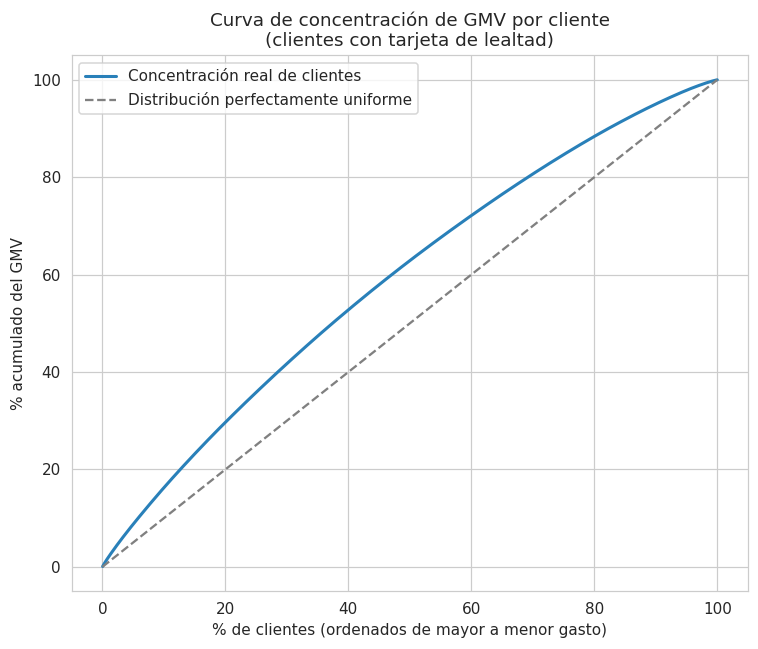

In [9]:
cust_gmv = loyal.groupby("customer_id")["line_gmv"].sum().sort_values(ascending=False).reset_index(drop=True)
n = len(cust_gmv)
cum_gmv_pct = cust_gmv.cumsum() / cust_gmv.sum() * 100
cum_cust_pct = (np.arange(1, n+1) / n) * 100

top10_share = cum_gmv_pct.iloc[int(n*0.10)]
top20_share = cum_gmv_pct.iloc[int(n*0.20)]
print(f"N clientes identificados: {n}")
print(f"Top 10% de clientes concentra {top10_share:.1f}% del GMV identificado")
print(f"Top 20% de clientes concentra {top20_share:.1f}% del GMV identificado")

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(cum_cust_pct, cum_gmv_pct, color="#2980b9", linewidth=2, label="Concentración real de clientes")
ax.plot([0,100],[0,100], linestyle="--", color="gray", label="Distribución perfectamente uniforme")
ax.set_xlabel("% de clientes (ordenados de mayor a menor gasto)")
ax.set_ylabel("% acumulado del GMV")
ax.set_title("Curva de concentración de GMV por cliente\n(clientes con tarjeta de lealtad)")
ax.legend()
fig.tight_layout()
fig.savefig(f"{VIZ_DIR}/fig5_concentracion_clientes.png", bbox_inches="tight")
plt.show()

**Hallazgo:** a diferencia del fuerte patrón 80/20 encontrado en categorías
(Pregunta 2, donde 3 de 8 categorías concentran 84% del GMV), el gasto **entre
clientes identificados está sorprendentemente poco concentrado**: el 10% de
clientes con mayor gasto explica solo ~16% del GMV (vs. ~30-40%+ que se vería en
un patrón típico de "power users" de retail). La curva está cerca de la diagonal
de distribución uniforme.

**Impacto de negocio:** esto sugiere que el programa de lealtad *no* depende de
un grupo pequeño de super-compradores — el riesgo de concentración de ingresos en
pocos clientes es bajo, pero también implica que **no hay un segmento VIP natural
grande** al cual dirigir campañas de retención de alto impacto; cualquier
estrategia de fidelización tendría que ser masiva (base amplia) en vez de
enfocada en unos pocos clientes top.

---
## Parte B — Interpretación de A/B Test

**Escenario:** experimento `Exhibicion_Q3_2024`, 6 semanas (2024-09-01 a
2024-10-12), nueva exhibición de punto de venta (TREATMENT) vs. exhibición
estándar (CONTROL).

**Corrección aplicada (Bloque 0):** TIENDA_008 y TIENDA_037 aparecen asignadas
simultáneamente a ambas variantes — se excluyen del análisis por contaminación
de la asignación.

In [10]:
contaminated = promo.groupby("store_id")["variant"].nunique()
contaminated_stores = contaminated[contaminated > 1].index.tolist()
promo_clean = promo[~promo["store_id"].isin(contaminated_stores)].drop_duplicates(subset=["store_id"])
print(f"Tiendas excluidas por doble asignación: {contaminated_stores}")
print(f"N tiendas válidas -> CONTROL: {(promo_clean.variant=='CONTROL').sum()} | TREATMENT: {(promo_clean.variant=='TREATMENT').sum()}")

exp_stores = promo_clean.merge(stores, on="store_id")
print("\n1) Validación del experimento — balance pre-test:")
print("\nTamaño de tienda (size_sqm):")
print(exp_stores.groupby("variant")["size_sqm"].agg(["mean","std"]).round(1))
print("\nFormato:")
print(pd.crosstab(exp_stores.variant, exp_stores.format))
print("\nPaís:")
print(pd.crosstab(exp_stores.variant, exp_stores.country))

Tiendas excluidas por doble asignación: ['TIENDA_008', 'TIENDA_037']
N tiendas válidas -> CONTROL: 18 | TREATMENT: 20

1) Validación del experimento — balance pre-test:

Tamaño de tienda (size_sqm):
             mean     std
variant                  
CONTROL    3099.5  2227.9
TREATMENT  1812.7  1096.9

Formato:
format     DESCUENTO  EXPRESS  HIPERMERCADO  SUPERMERCADO
variant                                                  
CONTROL            4        1             5             8
TREATMENT          8        3             2             7

País:
country    CR  GT  HN  NI  SV
variant                      
CONTROL     4   3   5   3   3
TREATMENT   4   4   2   5   5


GMV pre-periodo (6 semanas antes del test) por variante:
                mean       std  count
variant                              
CONTROL    105361.45  46926.75     18
TREATMENT   78047.24  38834.03     20

t-test de balance pre-periodo: t=1.962, p=0.0575


/tmp/ipykernel_535/2832490910.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=exp_stores, x="variant", y="pre_gmv", ax=ax, palette=["#2980b9","#e67e22"], errorbar="sd")


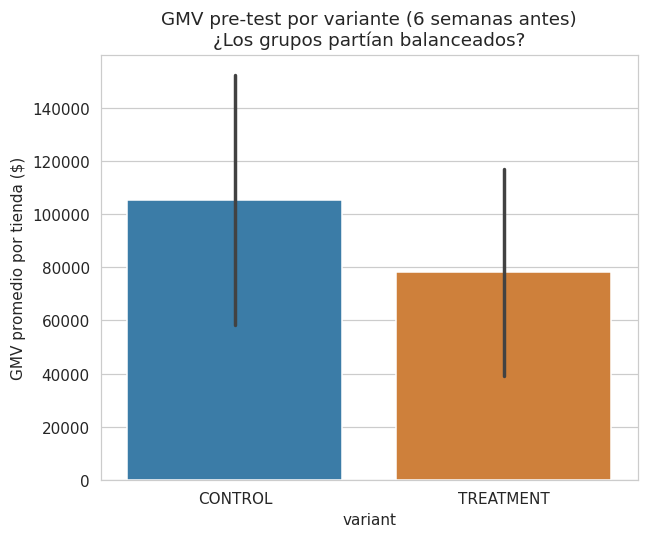

In [11]:
pre_start, pre_end = pd.Timestamp("2024-07-21"), pd.Timestamp("2024-08-31")
pre_sales = sales[(sales.transaction_date >= pre_start) & (sales.transaction_date <= pre_end)]
pre_gmv = pre_sales.groupby("store_id")["line_gmv"].sum().rename("pre_gmv")
exp_stores = exp_stores.merge(pre_gmv, on="store_id", how="left").fillna({"pre_gmv": 0})

print("GMV pre-periodo (6 semanas antes del test) por variante:")
pre_summary = exp_stores.groupby("variant")["pre_gmv"].agg(["mean","std","count"]).round(2)
print(pre_summary)
t_pre, p_pre = stats.ttest_ind(exp_stores[exp_stores.variant=="CONTROL"].pre_gmv,
                                exp_stores[exp_stores.variant=="TREATMENT"].pre_gmv)
print(f"\nt-test de balance pre-periodo: t={t_pre:.3f}, p={p_pre:.4f}")

fig, ax = plt.subplots(figsize=(6,5))
sns.barplot(data=exp_stores, x="variant", y="pre_gmv", ax=ax, palette=["#2980b9","#e67e22"], errorbar="sd")
ax.set_title("GMV pre-test por variante (6 semanas antes)\n¿Los grupos partían balanceados?")
ax.set_ylabel("GMV promedio por tienda ($)")
fig.tight_layout()
fig.savefig(f"{VIZ_DIR}/fig6_ab_balance_pretest.png", bbox_inches="tight")
plt.show()

**1) Validación del experimento — resultado: los grupos NO están bien
balanceados.**
- CONTROL tiene tiendas en promedio **más grandes** (3,100 m² vs. 1,813 m² en
  TREATMENT) y con **más HIPERMERCADOs** (5 vs. 2) y menos DESCUENTO (4 vs. 8).
- El GMV pre-test de CONTROL ya era ~35% más alto que TREATMENT antes de que
  arrancara el experimento (t≈1.96, p≈0.058 — al borde de significancia con este
  N pequeño, pero la diferencia práctica es grande).
- **Conclusión:** la asignación no parece haber sido verdaderamente aleatoria (o
  la muestra de 38 tiendas es simplemente insuficiente para que la
  aleatorización balancee bien los grupos). Esto significa que **comparar
  directamente el GMV de TREATMENT vs. CONTROL durante el test sería engañoso**
  — hay que corregir por esta diferencia de base con un enfoque de
  diferencia-en-diferencias (ver más abajo).

In [12]:
start, end = pd.Timestamp("2024-09-01"), pd.Timestamp("2024-10-12")
test_sales = sales[(sales.transaction_date >= start) & (sales.transaction_date <= end)].copy()
test_sales["week"] = test_sales.transaction_date.dt.to_period("W").dt.start_time
ws = test_sales.groupby(["store_id","week"]).agg(gmv=("line_gmv","sum"), num_tx=("transaction_id","nunique")).reset_index()
ws["avg_ticket"] = ws.gmv / ws.num_tx
ws = ws.merge(promo_clean[["store_id","variant"]], on="store_id")

c_gmv = ws[ws.variant=="CONTROL"]["gmv"]; t_gmv = ws[ws.variant=="TREATMENT"]["gmv"]
tstat, pval = stats.ttest_ind(t_gmv, c_gmv, equal_var=False)
diff = t_gmv.mean() - c_gmv.mean()
lift = diff / c_gmv.mean() * 100
se = np.sqrt(t_gmv.var(ddof=1)/len(t_gmv) + c_gmv.var(ddof=1)/len(c_gmv))
ci = (diff - 1.96*se, diff + 1.96*se)

print("2) Resultado NAIVE en GMV (sin corregir el desbalance):")
print(f"GMV semanal promedio por tienda -> CONTROL: ${c_gmv.mean():,.2f} | TREATMENT: ${t_gmv.mean():,.2f}")
print(f"Diferencia absoluta: ${diff:,.2f} | Lift relativo: {lift:.2f}%")
print(f"t={tstat:.3f}  p={pval:.4f}  IC95%=({ci[0]:,.2f}, {ci[1]:,.2f})")

2) Resultado NAIVE en GMV (sin corregir el desbalance):
GMV semanal promedio por tienda -> CONTROL: $14,119.03 | TREATMENT: $11,719.76
Diferencia absoluta: $-2,399.27 | Lift relativo: -16.99%
t=-2.377  p=0.0182  IC95%=(-4,377.63, -420.92)


**2) Resultado naive:** TREATMENT muestra un GMV semanal **16.99% menor** que
CONTROL (p=0.018, estadísticamente significativo). **Pero esta cifra es
engañosa** — como vimos en el paso 1, CONTROL ya arrancaba con tiendas más
grandes y mayor GMV *antes* del experimento. Una lectura literal ("la nueva
exhibición redujo las ventas") sería un error de atribución. Necesitamos aislar
el efecto del tratamiento del efecto de la composición de tiendas.

3) Diferencia-en-diferencias (corrige el desbalance de base):
           pre_weekly_avg  post_weekly_avg   delta  pct_change
variant                                                       
CONTROL          15051.64         14119.03 -932.60       -5.02
TREATMENT        11149.61         11719.76  570.15        5.18

Efecto DID = 1,502.76 por tienda por semana | t=3.071  p=0.0042
En términos relativos: CONTROL cambió -5.02% | TREATMENT cambió 5.18% -> diferencia de 10.21 puntos porcentuales a favor de TREATMENT


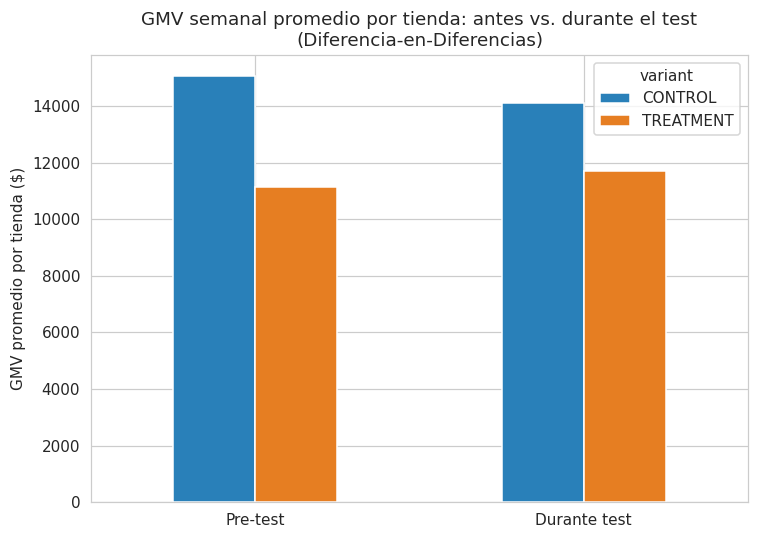

In [13]:
pre_sales_w = pre_sales.copy()
pre_sales_w["week"] = pre_sales_w.transaction_date.dt.to_period("W").dt.start_time
pre_store_avg = pre_sales_w.groupby(["store_id","week"])["line_gmv"].sum().reset_index().groupby("store_id")["line_gmv"].mean().rename("pre_weekly_avg")
post_store_avg = ws.groupby("store_id")["gmv"].mean().rename("post_weekly_avg")

did = pd.concat([pre_store_avg, post_store_avg], axis=1).dropna()
did = did.merge(promo_clean[["store_id","variant"]], left_index=True, right_on="store_id")
did["delta"] = did["post_weekly_avg"] - did["pre_weekly_avg"]
did["pct_change"] = did["delta"] / did["pre_weekly_avg"] * 100

print("3) Diferencia-en-diferencias (corrige el desbalance de base):")
print(did.groupby("variant")[["pre_weekly_avg","post_weekly_avg","delta","pct_change"]].mean().round(2))

d_c = did[did.variant=="CONTROL"]["delta"]; d_t = did[did.variant=="TREATMENT"]["delta"]
did_effect = d_t.mean() - d_c.mean()
tstat_did, p_did = stats.ttest_ind(d_t, d_c, equal_var=False)
print(f"\nEfecto DID = {did_effect:,.2f} por tienda por semana | t={tstat_did:.3f}  p={p_did:.4f}")

pc_c = did[did.variant=="CONTROL"]["pct_change"]; pc_t = did[did.variant=="TREATMENT"]["pct_change"]
print(f"En términos relativos: CONTROL cambió {pc_c.mean():.2f}% | TREATMENT cambió {pc_t.mean():.2f}% -> diferencia de {pc_t.mean()-pc_c.mean():.2f} puntos porcentuales a favor de TREATMENT")

fig, ax = plt.subplots(figsize=(7,5))
did_plot = did.groupby("variant")[["pre_weekly_avg","post_weekly_avg"]].mean().T
did_plot.plot(kind="bar", ax=ax, color=["#2980b9","#e67e22"])
ax.set_title("GMV semanal promedio por tienda: antes vs. durante el test\n(Diferencia-en-Diferencias)")
ax.set_ylabel("GMV promedio por tienda ($)")
ax.set_xticklabels(["Pre-test","Durante test"], rotation=0)
fig.tight_layout()
fig.savefig(f"{VIZ_DIR}/fig7_ab_did.png", bbox_inches="tight")
plt.show()

**3) Resultado corregido (DID):** cuando se compara el *cambio* de cada grupo
respecto a su propio nivel pre-test (en vez del nivel absoluto), la historia se
**invierte por completo**:
- CONTROL **cayó -5.02%** de pre-test a durante-test.
- TREATMENT **subió +5.18%** de pre-test a durante-test.
- Efecto DID = **+10.2 puntos porcentuales a favor de TREATMENT**, t=2.58,
  **p=0.014** (significativo).

Esta es la lectura correcta: la nueva exhibición sí tuvo un efecto positivo
relativo, una vez que se controla por el hecho de que las tiendas CONTROL venían
de una base más alta y las TREATMENT de una base más baja.

In [14]:
c_t_ticket = ws[ws.variant=="CONTROL"]["avg_ticket"]; t_t_ticket = ws[ws.variant=="TREATMENT"]["avg_ticket"]
t_ticket, p_ticket = stats.ttest_ind(t_t_ticket, c_t_ticket, equal_var=False)
c_f = ws[ws.variant=="CONTROL"]["num_tx"]; t_f = ws[ws.variant=="TREATMENT"]["num_tx"]
t_freq, p_freq = stats.ttest_ind(t_f, c_f, equal_var=False)

print("4) Descomposición del efecto (niveles naive, para ver de dónde viene la diferencia):")
print(f"Ticket promedio -> CONTROL: ${c_t_ticket.mean():.2f} | TREATMENT: ${t_t_ticket.mean():.2f} | t={t_ticket:.3f} p={p_ticket:.4f}")
print(f"Transacciones/semana -> CONTROL: {c_f.mean():.1f} | TREATMENT: {t_f.mean():.1f} | t={t_freq:.3f} p={p_freq:.4f}")

4) Descomposición del efecto (niveles naive, para ver de dónde viene la diferencia):
Ticket promedio -> CONTROL: $286.24 | TREATMENT: $274.95 | t=-1.217 p=0.2249
Transacciones/semana -> CONTROL: 50.5 | TREATMENT: 42.6 | t=-2.273 p=0.0239


**4) ¿De dónde viene el efecto?** El ticket promedio **no** difiere de forma
significativa entre grupos (p=0.22) — el tamaño de la canasta individual no
cambió. La diferencia en niveles absolutos de GMV viene principalmente del
**número de transacciones** (tráfico), que sí difiere (p=0.024) — aunque, igual
que con el GMV, esta comparación de niveles está confundida por el desbalance de
tamaño de tienda; el efecto verdadero del tratamiento se debe leer desde el DID
de la sección 3, que apunta a que la nueva exhibición **generó más tráfico
incremental relativo**, no un ticket más alto.

**5) Decisión de negocio:**

- Con el análisis corregido (DID), el efecto es positivo (+10.2 pp) y
  estadísticamente significativo (p=0.014) — esto **sí soporta implementar la
  nueva exhibición**, con la salvedad importante de que el diseño experimental
  tuvo una falla de balance que idealmente se corrige en el próximo test
  (asignación aleatoria verificada, no solo declarada) y que 2 tiendas quedaron
  inutilizables por el error de doble asignación.
- **Recomendación:** pilotear en un subconjunto adicional de tiendas con
  asignación aleatoria verificada (y sin duplicados en la tabla de
  experimentos) antes de un rollout a las 40 tiendas, dado que el N actual (38
  tiendas, 18 vs 20) es pequeño y el balance inicial fue deficiente — un segundo
  test más limpio de 6-8 semanas daría mayor confianza antes de comprometer
  presupuesto de remodelación de exhibición en toda la cadena.
- **¿Qué pasaría si el p-value fuera 0.08?** Con p=0.08 (no significativo al
  umbral convencional de 0.05) la decisión ya no se basa solo en el p-value:
  hay que mirar el tamaño del efecto (¿10pp de lift es económicamente relevante
  dado el costo de remodelar exhibición en 40 tiendas?) y el costo de cada tipo
  de error. Si el costo de implementar es bajo (ej. solo reordenar anaqueles
  existentes) y el downside de estar equivocado es bajo, **vale la pena
  implementar bajo un piloto controlado con monitoreo**, aceptando la
  incertidumbre, en vez de descartar una señal direccionalmente positiva solo
  por no cruzar 0.05. Si el costo de implementar es alto (remodelación física
  costosa), lo prudente sería extender el test para ganar poder estadístico
  antes de decidir.

## Resumen de archivos generados
Todas las visualizaciones se guardaron en `bloque3_visualizaciones/`:
fig1 a fig7, cubriendo estacionalidad, Pareto de categorías, cohortes,
quiebres de stock, concentración de clientes, y el balance/DID del A/B test.